Figure 4 m and n

This code was written using this library versions 
NumPy: 1.26.4
Pandas: 3.0.3
SciPy: 1.13.1
Matplotlib: 3.10.8

In [75]:
#Libraries

import numpy as np
import pandas as pd
import scipy as scipy
import matplotlib as matplotlib
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import time as time_module
import os
import ctypes
import matplotlib.pyplot as plt
import random

Figure m

[control] (single swap) Using fixed priors: r0=(0.0, 0.01), d=(0.0, 0.05), f=(0.0, 0.7)
[control] No previous progress. Starting from scratch.

[control] Starting Bootstrap... Maximum 1200 iterations or until convergence.

  [control] Iteration 1/1200 | block=coupled [coupled t=14 idx 19->18] | r0=0.00485 d=0.00933 f=0.15180 | 33.9s/iter
  [control] Iteration 2/1200 | block=coupled [coupled t=7 idx 7->4] | r0=0.00491 d=0.00924 f=0.16500 | 36.0s/iter
  [control] Iteration 3/1200 | block=coupled [coupled t=14 idx 18->21] | r0=0.00494 d=0.00921 f=0.16091 | 32.9s/iter
  [control] Iteration 4/1200 | block=coupled [coupled t=14 idx 20->17] | r0=0.00500 d=0.00913 f=0.16830 | 32.5s/iter
  [control] Iteration 5/1200 | block=nd [Nd t=7 idx 2->3] | r0=0.00493 d=0.00853 f=0.15677 | 34.0s/iter
  [control] Iteration 6/1200 | block=nd [Nd t=14 idx 11->16] | r0=0.00492 d=0.00926 f=0.16301 | 35.7s/iter
  [control] Iteration 7/1200 | block=nd  | r0=0.00492 d=0.00926 f=0.16295 | 36.5s/iter
  [control] It

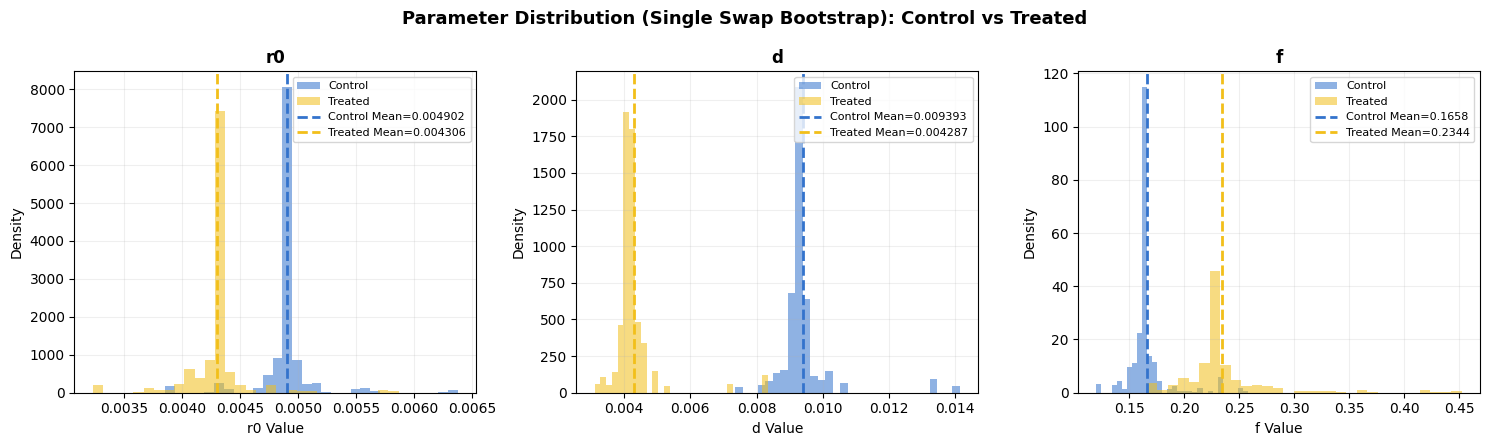

In [ ]:
# Define a seed 
SEED_GLOBAL = 42

np.random.seed(SEED_GLOBAL)
random.seed(SEED_GLOBAL)

# ===================================================
# Color Palette Definition
# ===================================================

COLOR_CONTROL = (0.2, 0.45, 0.8)    # vehicle / control
COLOR_TRATADO = (0.95, 0.75, 0.1)   # treatment / CCPE

# ===================================================
# General Configuration
# ===================================================

ALFA_FIXED = 4.0                  # alfa parameter
TAU_FIXED = 0.0                   
RELATIVE_FLOOR = 0.1              # Differs by the noise of your data

N_MAX = 14
TLIM_R = 9.0                      

# ===================================================
# Iteration and Convergence Criteria
# ===================================================

MAX_ITERATIONS = 1200             # Maximum iteration limit
CONVERGENCE_BLOCK_SIZE = 50       # Evaluate stability every N iterations
RELATIVE_TOLERANCE = 0.02         # 2% variation in 95% CI width
PATIENCE = 3                      # Consecutive blocks required to validate convergence

# File Paths
PATH_COUPLED_CONTROL = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\NEW Veh Data Completa2.csv'
PATH_ND_CONTROL      = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\ND Veh Data.csv'

PATH_COUPLED_TREATED = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\NEW Ccpe Data Completa.csv'
PATH_ND_TREATED      = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\ND Ccpe Data.csv'

PATH_RESULTS_CONTROL = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\bootstrap_S_SWAP_control.csv'
PATH_RESULTS_TREATED = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\bootstrap_S_SWAP_treated.csv'
PATH_OUTPUT_GRAPH    = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\distribution_S_SWAP_parameters.png'

# --- Prior Bounds ---
PRIORS_BOUNDS = [
    (0.0, 0.01),  # r0
    (0.0, 0.05),  # d
    (0.0, 0.7)    # f
]

DE_POPSIZE  = 8
DE_MAXITER  = 150
DE_TOL      = 1e-5

# ===================================================
# 1. System Suspension / Power Managment
# ===================================================

# Keeps the system awake during long-running computations.

def prevent_sleep():
    ES_CONTINUOUS = 0x80000000
    ES_SYSTEM_REQUIRED = 0x00000001
    ES_DISPLAY_REQUIRED = 0x00000002
    ctypes.windll.kernel32.SetThreadExecutionState(
        ES_CONTINUOUS | ES_SYSTEM_REQUIRED | ES_DISPLAY_REQUIRED
    )

def allow_sleep():
    ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)

# ===================================================
# 2. Multi-Parameter Convergence Detector 
# ===================================================

# It evaluates the stability of the 95% Confidence Interval (CI) width over cumulaitive
# blocks of iterations (in this case we set 50).

def detect_bootstrap_convergence(value_history, block_size=50,
                                  relative_tolerance=0.02, patience=3):

# Tracks how much the 95% CI width changes between consecutive checkpoints. If the relative
# change stays below a threshold (2%) for a designated number of blocks (patience), that
# parameter is marked as converged. 

    values = np.asarray(value_history)
    n = len(values) # number of iterations collected so far
    if n < block_size * (patience + 1): #checks if there are enough iterations to evaluate stability
        return {'converged': False, 'width_history': []}

    checkpoints = range(block_size, n + 1, block_size)
    widths = []
    for cutoff in checkpoints:
        sub = values[:cutoff] #takes the cumulative subset of values up to the current checkpoint
        ci_low, ci_high = np.percentile(sub, [2.5, 97.5]) #calculates 95% CI boundaries
        widths.append(ci_high - ci_low) #computes the width of the interval and stores it

    relative_changes = [ #computes the fractional change in CI between consecutive checkpoints
        abs(widths[i] - widths[i - 1]) / abs(widths[i - 1]) if widths[i - 1] != 0 else np.inf
        for i in range(1, len(widths))
    ]

    converged = False
    if len(relative_changes) >= patience:
        converged = all(c < relative_tolerance for c in relative_changes[-patience:])
    #Inspects the last relative_changes entries (patience)  

    return {'converged': converged, 'width_history': widths} #dictionary with status of boolean variable convergance and sequences of CI widths. 



def detect_multiparam_convergence(histories, block_size=50,
                                    relative_tolerance=0.02, patience=3):

# Convergance is reached when all parameters meet the stability criteria.

    states = {}
    for name, hist in histories.items():
        states[name] = detect_bootstrap_convergence( #runs it for each parameter
            hist, block_size, relative_tolerance, patience
        )

    all_have_data = all(len(e['width_history']) > 0 for e in states.values()) #checks all the parameters were evaluated
    all_converged = all_have_data and all(e['converged'] for e in states.values()) #Deetermines global convergence: returns True is the three converged == true.

    return {'converged': all_converged, 'states_per_parameter': states}

# ===================================================
# 3. Sigma Calculation
# ===================================================

# This function prepares sigmas for parameter fitting and optimization algorithms.
# Replaces missing to prevent zero uncertainties that cause division-by-zero errors and handling Nan values.

# If std is 0, the relative floor is calculated from the nearest non-zero neighbour.
# The final uncertainty value is set to the maximum between std and floor value, to prevent
# division by zero. 

def calculate_sigma(std_array, obs_values, t_array, relative_floor=0.1):
    sigma = np.array(std_array, dtype=float).copy()
    obs_values = np.array(obs_values, dtype=float)
    t_array = np.array(t_array, dtype=float)

# Impute NaNs with the global mean of available uncertainties
    idx_nan = np.where(np.isnan(sigma))[0]
    if len(idx_nan) > 0:
        valid_mean = np.nanmean(sigma)
        if np.isnan(valid_mean):
            valid_mean = 0.0
        sigma[idx_nan] = valid_mean

    floor = relative_floor * np.abs(obs_values)
    idx_zero = np.where(obs_values == 0)[0]
    idx_non_zero = np.where(obs_values != 0)[0]

    if len(idx_non_zero) > 0:
        for i in idx_zero:
            nearest_idx = idx_non_zero[np.argmin(np.abs(t_array[idx_non_zero] - t_array[i]))]
            local_scale = np.abs(obs_values[nearest_idx])
            floor[i] = relative_floor * local_scale
    else:
        floor[idx_zero] = relative_floor

    sigma = np.maximum(sigma, floor)
    return sigma

# ===================================================
# 4. Mathematical Model
# ===================================================

# Defines the core system of ordinary differential equarions (ODEs) described in the method section. 

def analytical_system_equations(t, y, r0, d, f, N_max, tlim_r=9.0):
    n = y[0:N_max]
    N = y[N_max]
    Nc = y[N_max + 1]
    Nd = y[N_max + 2]

    n0 = 32
    dndt = np.zeros(N_max)

    if t < tlim_r:
        r = r0 * (t**2)
    else:
        r = r0 * (7**2 / 11.088)

    summation = sum((i + 1) * f * n[i] for i in range(1, N_max))
    dndt[0] = -r * n[0] + d * (2 * n[1] - n[0]) + 2 * f * n[1] + summation

    for idx in range(1, N_max):
        i = idx + 1
        term_r = r * ((i - 1) * n[idx - 1] - i * n[idx])
        n_plus_1 = n[idx + 1] if idx < (N_max - 1) else 0.0
        term_d = d * ((i + 1) * n_plus_1 - i * n[idx])
        term_f = f * ((i + 1) * n_plus_1 - i * n[idx])
        dndt[idx] = term_r + term_d + term_f

    dNdt = r * N - d * N
    dNcdt = f * N - (d + f) * n[0]

    if t < TAU_FIXED:
        dNDdt = 0.0
    else:
        if (t - TAU_FIXED) < tlim_r:
            N_past = n0 * np.exp((r0 * (t - TAU_FIXED)**3 / 3) - d * (t - TAU_FIXED))
        else:
            N_past = n0 * np.exp((r0 * (tlim_r)**3 / 3) - d * tlim_r) + \
                     ((r0 * (7**2 / 11.088)) - d) * (t - TAU_FIXED - tlim_r)
        dNDdt = ALFA_FIXED * d * N_past

    return np.concatenate([dndt, [dNdt], [dNcdt], [dNDdt]])


# ===================================================
# 5. Weighted Error Function
# ===================================================

# Function for optimization. It numerically integrates a system of differential equations 
# (Section 4) and compares the output against experimental data to return a weighted
# Mean Squared Error (MSE).

def analytical_error_function(parameters, t_exp, N_exp, Nc_exp, Nd_exp,
                              w_N, w_Nc, w_Nd, N_max, tlim_r, y0_fixed):
    r0, d, f = parameters

    sol = solve_ivp(
        analytical_system_equations,
        [t_exp[0], t_exp[-1]],
        y0_fixed,
        args=(r0, d, f, N_max, tlim_r),
        t_eval=t_exp,
        method='Radau'
    )

    if sol.status != 0:
        return 1e12

    N_sim  = sol.y[N_max]
    Nc_sim = sol.y[N_max + 1]
    Nd_sim = sol.y[N_max + 2]

    res_N  = w_N  * (N_sim  - N_exp)**2
    res_Nc = w_Nc * (Nc_sim - Nc_exp)**2
    res_Nd = w_Nd * (Nd_sim - Nd_exp)**2

    weight_sum = np.sum(w_N) + np.sum(w_Nc) + np.sum(w_Nd)
    mse = (np.sum(res_N) + np.sum(res_Nc) + np.sum(res_Nd)) / weight_sum

    return mse

# ===================================================
# 6. Single Swap: Random selection of 1 time point and 1 element within it
# ===================================================

# Implements a single-point bootrstap sample technique. It randomly selects a time 
# point in a dataframe, picks one observation at that time point and replaces its values with 
# a duplicate from another observation within the same time point.  

def single_data_swap(df, time_col):
    df2 = df.copy().reset_index(drop=True)

    idx_out = np.random.choice(df2.index)
    t_out = df2.loc[idx_out, time_col]

    candidates = df2.index[(df2[time_col] == t_out) & (df2.index != idx_out)]

    if len(candidates) == 0:
        return df2, {'applied': False, 'time': t_out, 'idx_removed': idx_out, 'idx_clone': None}

    idx_clone = np.random.choice(candidates)
    df2.loc[idx_out] = df2.loc[idx_clone]

    return df2, {'applied': True, 'time': t_out, 'idx_removed': idx_out, 'idx_clone': idx_clone}


# ===================================================
# 7. Recalculate Means and STD
# ===================================================

# Recalculates the summary statistics across specified variables. 

def recalculate_mean_std(df, time_col, value_columns, ref_times):
    mean_dict = {c: np.zeros(len(ref_times)) for c in value_columns}
    std_dict  = {c: np.zeros(len(ref_times)) for c in value_columns}

    for i, t in enumerate(ref_times):
        sub = df[df[time_col] == t]
        for c in value_columns:
            values = sub[c].values
            mean_dict[c][i] = np.mean(values)
            std_dict[c][i]  = np.std(values, ddof=1) if len(values) > 1 else np.nan

    return mean_dict, std_dict


# ===================================================
# 8. One Bootrstap Iteration (Single Swap)
# ===================================================

# Executes one complete bootrstap iteration. It randomly chooses one dataset to apply the swap,
# recalculates the means and standard deviations, computes variance weights, sets up the ODES
# conditions and uses differential_evolution to optimize and return parameters (r0, d, f).

def single_bootstrap_iteration(df_coupled_original, df_nd_original,
                               time_col_coupled, time_col_nd,
                               unique_times, coupled_columns, bounds):

    chosen_block = np.random.choice(['coupled', 'nd'])

    if chosen_block == 'coupled':
        df_coupled_boot, info_coupled = single_data_swap(df_coupled_original, time_col_coupled)
        df_nd_boot = df_nd_original.copy()
        info_nd = {'applied': False, 'time': None, 'idx_removed': None, 'idx_clone': None}
    else:
        df_coupled_boot = df_coupled_original.copy()
        info_coupled = {'applied': False, 'time': None, 'idx_removed': None, 'idx_clone': None}
        df_nd_boot, info_nd = single_data_swap(df_nd_original, time_col_nd)

    mean_coupled, std_coupled = recalculate_mean_std(
        df_coupled_boot, time_col_coupled, coupled_columns, unique_times
    )
    mean_nd, std_nd = recalculate_mean_std(
        df_nd_boot, time_col_nd, ['Nd'], unique_times
    )

    t_exp  = unique_times
    N_exp  = mean_coupled['N']
    Nc_exp = mean_coupled['Nc']
    n1_exp = mean_coupled['n1']
    n2_exp = mean_coupled['n2']
    n3_exp = mean_coupled['n3']
    Nd_exp = mean_nd['Nd']

    N_sd  = std_coupled['N']
    Nc_sd = std_coupled['Nc']
    Nd_sd = std_nd['Nd']

    sigma_N  = calculate_sigma(N_sd,  N_exp,  t_exp, RELATIVE_FLOOR)
    sigma_Nc = calculate_sigma(Nc_sd, Nc_exp, t_exp, RELATIVE_FLOOR)
    sigma_Nd = calculate_sigma(Nd_sd, Nd_exp, t_exp, RELATIVE_FLOOR)

    w_N  = 1.0 / sigma_N**2
    w_Nc = 1.0 / sigma_Nc**2
    w_Nd = 1.0 / sigma_Nd**2

    initial_n = np.zeros(N_MAX)
    initial_n[0] = n1_exp[0]
    initial_n[1] = n2_exp[0]
    initial_n[2] = n3_exp[0]
    y0_fixed = np.concatenate([initial_n, [N_exp[0]], [Nc_exp[0]], [0.0]])

    current_seed = int(np.random.randint(0, 2**31 - 1))

    result = differential_evolution(
        analytical_error_function, bounds=bounds,
        args=(t_exp, N_exp, Nc_exp, Nd_exp, w_N, w_Nc, w_Nd, N_MAX, TLIM_R, y0_fixed),
        strategy='best1bin', popsize=DE_POPSIZE, tol=DE_TOL, maxiter=DE_MAXITER,
        seed=current_seed, disp=False
    )

    r0_opt, d_opt, f_opt = result.x
    return r0_opt, d_opt, f_opt, result.fun, result.success, chosen_block, info_coupled, info_nd

# ===================================================
# 9. Plotting Functions
# ===================================================

# Generates and display plots that show the distribution of the model parameters between
# control (Veh) and treated (cCpe) experimental groups, including mean indicator lines for each condition.

def plot_parameter_distributions(df_boot_control, df_boot_treated,
                                 parameters=('r0', 'd', 'f'), output_path=None):
    fig, axes = plt.subplots(1, len(parameters), figsize=(5 * len(parameters), 4.5))
    if len(parameters) == 1:
        axes = [axes]

    for ax, param in zip(axes, parameters):
        vals_c = df_boot_control[param].values
        vals_t = df_boot_treated[param].values

        ax.hist(vals_c, bins=30, alpha=0.55, color=COLOR_CONTROL, label='Control', density=True)
        ax.hist(vals_t, bins=30, alpha=0.55, color=COLOR_TRATADO, label='Treated', density=True)

        mean_c = vals_c.mean()
        mean_t = vals_t.mean()

        ax.axvline(mean_c, color=COLOR_CONTROL, linestyle='--', linewidth=2, label=f'Control Mean={mean_c:.4g}')
        ax.axvline(mean_t, color=COLOR_TRATADO, linestyle='--', linewidth=2, label=f'Treated Mean={mean_t:.4g}')

        ax.set_title(param, fontsize=12, fontweight='bold')
        ax.set_xlabel(f'{param} Value')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)

    plt.suptitle('Parameter Distribution (Single Swap Bootstrap): Control vs Treated', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150)
        print(f"Plot saved to: {output_path}")
    plt.show()


# ===================================================
# 10. Single Swap Bootstrap with multi-parameter convergence
# ===================================================

# Manages the full bootrstap workflow for an experimental condition. It loops
# single_bootsrtap_iteration (Section 8) until maximum iterations or convergence criteria are
# met, and logs progress per iteration. 

def run_group_bootstrap(path_coupled, path_nd, path_results, group_name):

    df_coupled_original = pd.read_csv(path_coupled, sep=';')
    df_coupled_original.columns = df_coupled_original.columns.str.strip()

    df_nd_original = pd.read_csv(path_nd, sep=';')
    df_nd_original.columns = df_nd_original.columns.str.strip()

    time_col_coupled = df_coupled_original.columns[0]
    time_col_nd      = df_nd_original.columns[0]

    unique_times = np.sort(df_coupled_original[time_col_coupled].unique())
    coupled_columns = ['n1', 'Nc', 'N', 'n2', 'n3']

    bounds = PRIORS_BOUNDS
    print(f"[{group_name}] (single swap) Using fixed priors: r0={bounds[0]}, d={bounds[1]}, f={bounds[2]}")

    history = {'r0': [], 'd': [], 'f': []}

    if os.path.exists(path_results):
        df_previous = pd.read_csv(path_results, sep=';')
        iterations_done = len(df_previous)
        history['r0'] = df_previous['r0'].tolist()
        history['d']  = df_previous['d'].tolist()
        history['f']  = df_previous['f'].tolist()
        print(f"[{group_name}] Previous progress found: {iterations_done} iterations. Continuing...")
    else:
        iterations_done = 0
        pd.DataFrame(columns=['group', 'iteration', 'chosen_block', 'r0', 'd', 'f',
                               'mse', 'converged']).to_csv(path_results, sep=';', index=False)
        print(f"[{group_name}] No previous progress. Starting from scratch.")

    # Check if max limit was reached
    if iterations_done >= MAX_ITERATIONS:
        print(f"[{group_name}] Already reached maximum allowed iterations ({MAX_ITERATIONS}).")
        return pd.read_csv(path_results, sep=';')

    print(f"\n[{group_name}] Starting Bootstrap... Maximum {MAX_ITERATIONS} iterations or until convergence.\n")
    t0 = time_module.time()

    for it in range(iterations_done, MAX_ITERATIONS):
        r0_opt, d_opt, f_opt, mse, converged, chosen_block, info_coupled, info_nd = single_bootstrap_iteration(
            df_coupled_original, df_nd_original,
            time_col_coupled, time_col_nd,
            unique_times, coupled_columns, bounds
        )

        history['r0'].append(r0_opt)
        history['d'].append(d_opt)
        history['f'].append(f_opt)

        row = pd.DataFrame([{
            'group': group_name, 'iteration': it, 'chosen_block': chosen_block,
            'r0': r0_opt, 'd': d_opt, 'f': f_opt,
            'mse': mse, 'converged': converged,
        }])
        row.to_csv(path_results, sep=';', index=False, mode='a', header=False)

        elapsed = time_module.time() - t0
        done_this_session = it - iterations_done + 1
        avg_per_iter = elapsed / done_this_session

        swap_detail = ""
        if chosen_block == 'coupled' and info_coupled['applied']:
            swap_detail = f"[coupled t={info_coupled['time']} idx {info_coupled['idx_removed']}->{info_coupled['idx_clone']}]"
        elif chosen_block == 'nd' and info_nd['applied']:
            swap_detail = f"[Nd t={info_nd['time']} idx {info_nd['idx_removed']}->{info_nd['idx_clone']}]"

        print(f"  [{group_name}] Iteration {it+1}/{MAX_ITERATIONS} | block={chosen_block} {swap_detail} | "
              f"r0={r0_opt:.5f} d={d_opt:.5f} f={f_opt:.5f} | {avg_per_iter:.1f}s/iter")

        # --- Convergence evaluation every N iterations ---
        if (it + 1) % CONVERGENCE_BLOCK_SIZE == 0:
            res_conv = detect_multiparam_convergence(
                history, CONVERGENCE_BLOCK_SIZE, RELATIVE_TOLERANCE, PATIENCE
            )
            if res_conv['converged']:
                print(f"\n[{group_name}] CONVERGENCE REACHED across all 3 parameters at iteration {it+1}")
                break

    print(f"\n[{group_name}] Completed ({len(history['r0'])} iterations processed).")
    return pd.read_csv(path_results, sep=';')


# ===================================================
# 11. Main Execution
# ===================================================

# Entry point script. Temporarily prevents the system sleep while managing the bootrstap
# pipelines for both experimental groups.

if __name__ == '__main__':
    prevent_sleep()
    try:
        df_control = run_group_bootstrap(
            PATH_COUPLED_CONTROL, PATH_ND_CONTROL, PATH_RESULTS_CONTROL, 'control'
        )
        df_treated = run_group_bootstrap(
            PATH_COUPLED_TREATED, PATH_ND_TREATED, PATH_RESULTS_TREATED, 'treated'
        )
    finally:
        allow_sleep()

# ===================================================
# 12. Significance Table and Plots
# ===================================================

# Performs comparative statistical inference on the resulting parameter distributions. It
# computes matrices across groups iterations to generate 95% confidence intervals and empirical
# p-values, exports the final summary csv and generates the comparison plots. 

if len(df_control) > 0 and len(df_treated) > 0:
    print(f"\n{'='*70}\nCOMPARISON Control vs Treated (SINGLE SWAP) — r0, d, f\n{'='*70}")
    print(f"Control Iterations: {len(df_control)} | Treated Iterations: {len(df_treated)}")

    comparison_summary = []

    for param in ['r0', 'd', 'f']:
        # Retrieve ALL data points for each group without clipping/trimming
        vals_control = df_control[param].values
        vals_treated = df_treated[param].values

        mean_control = np.mean(vals_control)
        std_control  = np.std(vals_control, ddof=1)
        mean_treated = np.mean(vals_treated)
        std_treated  = np.std(vals_treated, ddof=1)

        # Difference matrix across all independent iterations (Outer Subtract)
        # treated[:, None] converts array to column and subtracts entire control array
        diff_matrix = vals_treated[:, None] - vals_control
        differences = diff_matrix.ravel()  # Flatten the difference matrix

        ci_low, ci_high = np.percentile(differences, [2.5, 97.5])
        significant = (ci_low > 0) or (ci_high < 0)

        total_comparisons = len(differences)
        count_treated_greater = np.sum(differences > 0)
        count_control_greater = np.sum(differences < 0)
        count_equal           = np.sum(differences == 0)
            
        # Proportion of instances where Treated is GREATER than Control in combined distribution
        prop_treated_greater = np.mean(differences > 0)
        prop_control_greater = 1.0 - prop_treated_greater

        # Empirical overall two-tailed p-value
        p_empirical = 2 * min(prop_treated_greater, prop_control_greater)

        print(f"\n--- {param} ---")
        print(f"Control -> mean={mean_control:.6f}  std={std_control:.6f} (N={len(vals_control)})")
        print(f"Treated -> mean={mean_treated:.6f}  std={std_treated:.6f} (N={len(vals_treated)})")
        print(f"Total combined comparisons: {total_comparisons:,} ({len(vals_treated)} x {len(vals_control)})")
        print(f" - Treated > Control cases  (diff > 0): {count_treated_greater:,}")
        print(f" - Control > Treated cases  (diff < 0): {count_control_greater:,}")
        if count_equal > 0:
            print(f" - Treated == Control cases (diff = 0): {count_equal:,}")
        print(f"Difference (Treated - Control), 95% CI: [{ci_low:.6f}, {ci_high:.6f}]")
        print(f"Proportion P(Treated > Control) = {prop_treated_greater * 100:.2f}% | P(Control > Treated) = {prop_control_greater * 100:.2f}%")
        print(f"=> {'Significant' if significant else 'NOT Significant'} | Empirical p-value ≈ {p_empirical:.6e}")

        comparison_summary.append({
            'parameter': param,
            'mean_control': mean_control, 'std_control': std_control,
            'mean_treated': mean_treated, 'std_treated': std_treated,
            'mean_difference': np.mean(differences),
            'ci_95_low': ci_low, 'ci_95_high': ci_high,
            'total_comparisons': total_comparisons,
            'count_treated_greater': count_treated_greater,
            'count_control_greater': count_control_greater,
            'count_equal': count_equal,
            'prop_treated_greater': prop_treated_greater,
            'prop_control_greater': prop_control_greater,
            'significant': significant, 'p_empirical': p_empirical,
        })

    # --- Building and saving final table (outside the loop) ---
    df_summary = pd.DataFrame(comparison_summary)
    print(f"\n{'='*70}\nFINAL SUMMARY (SINGLE SWAP)\n{'='*70}")
    print(df_summary.to_string(index=False))

    path_summary = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\bootstrap_S_SWAP_comparison_summary.csv'
    df_summary.to_csv(path_summary, sep=';', index=False)
    print(f"\nSummary saved to: {path_summary}")

    # --- Single Plot (outside the loop) ---
    print("\nGenerating distribution plots for Single Swap...")
    plot_parameter_distributions(
        df_control,
        df_treated,
        output_path=PATH_OUTPUT_GRAPH
    )

Figure n

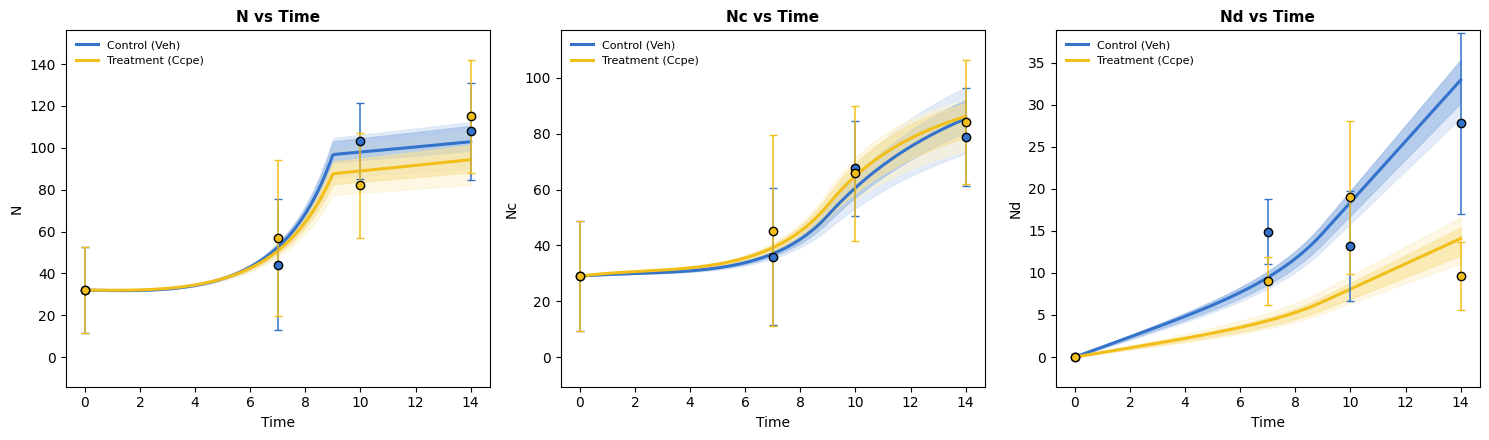

In [ ]:
# ===================================================
# Model Constants and Global configuration
# ===================================================

# Set ODE parameters and simulation bounds
ALPHA_FIXED = 4.0
TAU_FIXED = 0.0
N_MAX = 14
TLIM_R = 9.0

# Base color palettes for experimental conditions 
COLOR_CONTROL = (0.2, 0.45, 0.8)    # Control / Veh
COLOR_TREATED = (0.95, 0.75, 0.1)   # Treatment / cCpe


def lighten_color(color, factor):
    """Blend a color towards white. factor=0 -> original color, factor=1 -> white."""
    r, g, b = color
    return (r + (1 - r) * factor, g + (1 - g) * factor, b + (1 - b) * factor)

# ===================================================
# 1. Mathematical Model (ODEs)
# ===================================================

# Defines the core system of ordinary differential equarions (ODEs) described in the method section. 

def analytical_system_equations(t, y, r0, d, f, N_max, tlim_r=9.0):
    n = y[0:N_max]
    N = y[N_max]
    Nc = y[N_max + 1]
    Nd = y[N_max + 2]

    n0 = 32
    dndt = np.zeros(N_max)

    if t < tlim_r:
        r = r0 * (t ** 2)
    else:
        r = r0 * (7 ** 2 / 11.088)

    summation = sum((i + 1) * f * n[i] for i in range(1, N_max))
    dndt[0] = -r * n[0] + d * (2 * n[1] - n[0]) + 2 * f * n[1] + summation

    for idx in range(1, N_max):
        i = idx + 1
        term_r = r * ((i - 1) * n[idx - 1] - i * n[idx])
        n_plus_1 = n[idx + 1] if idx < (N_max - 1) else 0.0
        term_d = d * ((i + 1) * n_plus_1 - i * n[idx])
        term_f = f * ((i + 1) * n_plus_1 - i * n[idx])
        dndt[idx] = term_r + term_d + term_f

    dNdt = r * N - d * N
    dNcdt = f * N - (d + f) * n[0]

    if t < TAU_FIXED:
        dNDdt = 0.0
    else:
        if (t - TAU_FIXED) < tlim_r:
            N_past = n0 * np.exp((r0 * (t - TAU_FIXED) ** 3 / 3) - d * (t - TAU_FIXED))
        else:
            N_past = n0 * np.exp((r0 * (tlim_r) ** 3 / 3) - d * tlim_r) + \
                     ((r0 * (7 ** 2 / 11.088)) - d) * (t - TAU_FIXED - tlim_r)
        dNDdt = ALPHA_FIXED * d * N_past

    return np.concatenate([dndt, [dNdt], [dNcdt], [dNDdt]])

# ===================================================
# 2. Curve Simulation
# ===================================================

# Integrates the ODE system over a continuous time grid for a parameter set.
# If this fails it returns None. 

def simulate_curve(parameters, t_continuous, y0_fixed):
    r0, d, f = parameters
    sol = solve_ivp(
        analytical_system_equations, [t_continuous[0], t_continuous[-1]], y0_fixed,
        args=(r0, d, f, N_MAX, TLIM_R), t_eval=t_continuous, method='Radau'
    )
    if sol.status != 0:
        return None
    return {'N': sol.y[N_MAX], 'Nc': sol.y[N_MAX + 1], 'Nd': sol.y[N_MAX + 2]}

# ===================================================
# 3. Data Loading
# ===================================================

# Loads experimental data and initial conditions from csv files.

def load_experimental_data(training_path, csv_sep=';'):
    df_train = pd.read_csv(training_path, sep=csv_sep)
    df_train.columns = df_train.columns.str.strip()

    t_exp = df_train['time_prom'].values
    N_exp = df_train['N_prom'].values
    Nc_exp = df_train['Nc_prom'].values
    Nd_exp = df_train['ND_prom'].values

    N_std = df_train['N_std'].values if 'N_std' in df_train.columns else None
    Nc_std = df_train['Nc_std'].values if 'Nc_std' in df_train.columns else None
    Nd_std = df_train['ND_std'].values if 'ND_std' in df_train.columns else None

    n_initial = np.zeros(N_MAX)
    n_initial[0] = df_train['n1_prom'].values[0]
    n_initial[1] = df_train['n2_prom'].values[0]
    n_initial[2] = df_train['n3_prom'].values[0]
    y0_fixed = np.concatenate([n_initial, [N_exp[0]], [Nc_exp[0]], [0.0]])

    return t_exp, N_exp, Nc_exp, Nd_exp, N_std, Nc_std, Nd_std, y0_fixed

# Loads bootrstap parameter samples from csv

def load_bootstrap(csv_path, csv_sep=';'):
    df = pd.read_csv(csv_path, sep=csv_sep)
    df.columns = df.columns.str.strip()
    for col in ['r0', 'd', 'f']:
        if col not in df.columns:
            raise ValueError(f"Bootstrap CSV missing column '{col}'. Found: {list(df.columns)}")
    return df

# ===================================================
# 4. Uncertainty Quantification and Confidence Bands
# ===================================================

# Simulation of the central curve using parameter means and computes upper/lower
# prediction envelopes for specified sigma levels (1 and 2).

def filter_box(df_boot, mu, std, k_sigma, parameters):
    mask = np.ones(len(df_boot), dtype=bool)
    for p in parameters:
        lower = mu[p] - k_sigma * std[p]
        upper = mu[p] + k_sigma * std[p]
        mask &= (df_boot[p].values >= lower) & (df_boot[p].values <= upper)
    return mask


def calculate_bootstrap_curve_and_bands(df_boot, t_continuous, y0_fixed,
                                         parameters=('r0', 'd', 'f'), levels=(1, 2)):
    mu = {p: df_boot[p].mean() for p in parameters}
    std = {p: df_boot[p].std(ddof=1) for p in parameters}

    central_curve = simulate_curve([mu[p] for p in parameters], t_continuous, y0_fixed)
    if central_curve is None:
        raise RuntimeError("Simulation with bootstrap mean did not converge.")

    max_level = max(levels)
    max_mask = filter_box(df_boot, mu, std, max_level, parameters)
    df_filtered_max = df_boot[max_mask].reset_index(drop=True)

    max_curves = {'N': [], 'Nc': [], 'Nd': []}
    for _, row in df_filtered_max.iterrows():
        params = [row[p] for p in parameters]
        curve = simulate_curve(params, t_continuous, y0_fixed)
        if curve is not None:
            for var in max_curves:
                max_curves[var].append(curve[var])
    for var in max_curves:
        max_curves[var] = np.array(max_curves[var])

    bands = {}
    for k in sorted(levels):
        if k == max_level:
            curves_k = max_curves
        else:
            mask_k = filter_box(df_filtered_max, mu, std, k, parameters)
            curves_k = {var: max_curves[var][mask_k] for var in max_curves}
        bands[k] = {var: (curves_k[var].min(axis=0), curves_k[var].max(axis=0)) for var in curves_k}

    return central_curve, bands, mu, std

# ===================================================
# 5. Plotting Functions
# ===================================================

# Plots mean trajectories, confidence envelopes and experimental data points.

def plot_combined_panel(ax, t_continuous,
                        curve_c, bands_c, t_exp_c, exp_c, std_c,
                        curve_t, bands_t, t_exp_t, exp_t, std_t,
                        variable, title, ylim=None):
    
    #Color shades for confidence intervals
    color_c_1s = lighten_color(COLOR_CONTROL, 0.55)
    color_c_2s = lighten_color(COLOR_CONTROL, 0.8)
    color_t_1s = lighten_color(COLOR_TREATED, 0.55)
    color_t_2s = lighten_color(COLOR_TREATED, 0.8)

    # Control
    low2c, high2c = bands_c[2][variable]
    low1c, high1c = bands_c[1][variable]
    ax.fill_between(t_continuous, low2c, high2c, color=color_c_2s, alpha=0.7, zorder=1)
    ax.fill_between(t_continuous, low1c, high1c, color=color_c_1s, alpha=0.7, zorder=2)
    ax.plot(t_continuous, curve_c[variable], color=COLOR_CONTROL, linewidth=2.2, zorder=4, label='Control (Veh)')

    # Treatment
    low2t, high2t = bands_t[2][variable]
    low1t, high1t = bands_t[1][variable]
    ax.fill_between(t_continuous, low2t, high2t, color=color_t_2s, alpha=0.6, zorder=1)
    ax.fill_between(t_continuous, low1t, high1t, color=color_t_1s, alpha=0.6, zorder=3)
    ax.plot(t_continuous, curve_t[variable], color=COLOR_TREATED, linewidth=2.2, zorder=5, label='Treatment (Ccpe)')

    # Overlay experimental data points (with error bar)
    if std_c is not None:
        ax.errorbar(t_exp_c, exp_c, yerr=std_c, fmt='o', color=COLOR_CONTROL,
                    ecolor=COLOR_CONTROL, markeredgecolor='black', elinewidth=1.1,
                    capsize=3, markersize=6, zorder=6)
    else:
        ax.scatter(t_exp_c, exp_c, color=COLOR_CONTROL, edgecolor='black', s=40, zorder=6)

    if std_t is not None:
        ax.errorbar(t_exp_t, exp_t, yerr=std_t, fmt='o', color=COLOR_TREATED,
                    ecolor=COLOR_TREATED, markeredgecolor='black', elinewidth=1.1,
                    capsize=3, markersize=6, zorder=6)
    else:
        ax.scatter(t_exp_t, exp_t, color=COLOR_TREATED, edgecolor='black', s=40, zorder=6)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel(variable)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(loc='upper left', frameon=False, fontsize=8)
    ax.grid(False)

# Calculates uniform Y-axis limits across both experimental dataset bounds.

def calculate_shared_ylim(bands_c, bands_t, exp_c, exp_t, std_c, std_t, variable, margin=0.10):
    max_candidates = [bands_c[2][variable][1].max(), bands_t[2][variable][1].max()]
    min_candidates = [bands_c[2][variable][0].min(), bands_t[2][variable][0].min()]

    std_c_vals = std_c if std_c is not None else np.zeros_like(exp_c)
    std_t_vals = std_t if std_t is not None else np.zeros_like(exp_t)
    max_candidates += [(exp_c + std_c_vals).max(), (exp_t + std_t_vals).max()]
    min_candidates += [(exp_c - std_c_vals).min(), (exp_t - std_t_vals).min()]

    y_max = max(max_candidates)
    y_min = min(0, min(min_candidates))
    rng = y_max - y_min
    return (y_min - margin * rng, y_max + margin * rng)

# ===================================================
# 6. Main Pipeline Function (Figure n Generation)
# ===================================================

# Executes the pipeline and plots the final figure

def figure_1x3(control_training_path, control_boot_df,
               treated_training_path, treated_boot_df,
               n_points_curve=300, output_path=None, output_pdf=None):

    # 1. Load experimental data
    t_exp_c, N_c, Nc_c, Nd_c, Nsd_c, Ncsd_c, Ndsd_c, y0_c = load_experimental_data(control_training_path)
    t_exp_t, N_t, Nc_t, Nd_t, Nsd_t, Ncsd_t, Ndsd_t, y0_t = load_experimental_data(treated_training_path)

    # 2. Define continuous evaluation time array
    t_min = min(t_exp_c[0], t_exp_t[0])
    t_max = max(t_exp_c[-1], t_exp_t[-1])
    t_continuous = np.linspace(t_min, t_max, n_points_curve)

    # 3. Simulate model
    curve_c, bands_c, mu_c, std_c = calculate_bootstrap_curve_and_bands(control_boot_df, t_continuous, y0_c)
    curve_t, bands_t, mu_t, std_t = calculate_bootstrap_curve_and_bands(treated_boot_df, t_continuous, y0_t)

    exp_values_c = {'N': N_c, 'Nc': Nc_c, 'Nd': Nd_c}
    exp_values_t = {'N': N_t, 'Nc': Nc_t, 'Nd': Nd_t}
    exp_std_c = {'N': Nsd_c, 'Nc': Ncsd_c, 'Nd': Ndsd_c}
    exp_std_t = {'N': Nsd_t, 'Nc': Ncsd_t, 'Nd': Ndsd_t}

    # 4. Generate figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    variables = ['N', 'Nc', 'Nd']

    for j, variable in enumerate(variables):
        ylim = calculate_shared_ylim(
            bands_c, bands_t, exp_values_c[variable], exp_values_t[variable],
            exp_std_c[variable], exp_std_t[variable], variable
        )
        plot_combined_panel(
            axes[j], t_continuous,
            curve_c, bands_c, t_exp_c, exp_values_c[variable], exp_std_c[variable],
            curve_t, bands_t, t_exp_t, exp_values_t[variable], exp_std_t[variable],
            variable, f'{variable} vs Time', ylim=ylim
        )

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150)
    if output_pdf:
        plt.savefig(output_pdf, format='pdf', bbox_inches='tight')
    plt.show()

# ===================================================
# 7. Execution Entry Point
# ===================================================

if __name__ == "__main__":
    CONTROL_AVG_PATH = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\veh_promedios.csv'
    TREATED_AVG_PATH = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\Ccpe_promedios.csv'

    CONTROL_BOOTSTRAP_PATH = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\bootstrap_S_SWAP_control.csv'
    TREATED_BOOTSTRAP_PATH = r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\bootstrap_S_SWAP_treated.csv'

    control_boot_df = load_bootstrap(CONTROL_BOOTSTRAP_PATH)
    treated_boot_df = load_bootstrap(TREATED_BOOTSTRAP_PATH)

    figure_1x3(
        CONTROL_AVG_PATH, control_boot_df,
        TREATED_AVG_PATH, treated_boot_df,
        output_path=r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\figure_1x3.png',
        output_pdf=r'C:\Users\pdelf\OneDrive\Documents\Proyecto Tejido Cardiaco\figure_1x3.pdf'
    )